# 06 — Market Basket Analysis (MBA)

Este notebook implementa **Market Basket Analysis** sobre el dataset de Instacart utilizando el algoritmo **Apriori** y **FP-Growth** (mlxtend).  
El análisis se realiza en dos niveles de granularidad:

1. **Nivel Aisle** (134 categorías): visión macro de qué secciones del supermercado se compran juntas.
2. **Nivel Producto** (top-200): reglas de asociación específicas entre productos para cross-selling.

**Objetivo de negocio:** identificar patrones de co-compra accionables para:
- Recomendaciones de productos complementarios.
- Optimización de la disposición de la tienda / app.
- Estrategias de bundling y promociones cruzadas.

## Sección 1: Setup e Imports

Importamos todas las bibliotecas necesarias y definimos las constantes globales del proyecto.  
- **mlxtend**: contiene los algoritmos MBA (`apriori`, `fpgrowth`, `association_rules`, `TransactionEncoder`).
- **networkx**: para graficar el grafo de reglas de asociación.
- **USE_FULL_DATA = True**: corre el análisis sobre las ~3.2M órdenes prior completas, lo que produce soportes y confianzas estadísticamente exactos en lugar de estimados sobre una muestra. Cambiar a `False` para usar `SAMPLE_SIZE = 500 000` como fallback de desarrollo rápido.
- **RANDOM_STATE = 42**: semilla de aleatoriedad para reproducibilidad.

In [2]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

import networkx as nx

%matplotlib inline
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# ── Constantes ────────────────────────────────────────────────────────────────
RAW_DIR       = os.path.join('..', 'data', 'raw', 'instacart')
PROCESSED_DIR = os.path.join('..', 'data', 'processed')
RANDOM_STATE  = 42

# USE_FULL_DATA = True  → dataset prior completo (~3.2M órdenes); recomendado.
# Cambiar a False + SAMPLE_SIZE para un run rápido de prueba / máquinas con ≤ 8 GB RAM.
USE_FULL_DATA = True
SAMPLE_SIZE   = 500_000   # usado solo si USE_FULL_DATA = False

os.makedirs(PROCESSED_DIR, exist_ok=True)
print('Setup completo.')
print(f'USE_FULL_DATA: {USE_FULL_DATA}')
print(f'RAW_DIR      : {os.path.abspath(RAW_DIR)}')
print(f'PROCESSED_DIR: {os.path.abspath(PROCESSED_DIR)}')

Setup completo.
USE_FULL_DATA: True
RAW_DIR      : c:\henry\ProyectoFinal-DataScience-Henry\data\raw\instacart
PROCESSED_DIR: c:\henry\ProyectoFinal-DataScience-Henry\data\processed


## Sección 2: Carga de Datos desde Raw CSVs

Cargamos únicamente las columnas necesarias de cada archivo para minimizar el uso de memoria:

- **orders.csv** → filtramos `eval_set == 'prior'` para usar solo las órdenes históricas (no el set de test/train de la competencia).
- **order_products__prior.csv** → relación order ↔ product.
- **products.csv** → nombres e identificadores de categoría (aisle).
- **aisles.csv** → nombres de las 134 categorías.

Finalmente hacemos un **merge en cadena** para obtener un único DataFrame enriquecido y optimizamos los tipos de datos a `int32` para reducir memoria.

In [3]:
# ── 1. Cargar orders (solo prior) ─────────────────────────────────────────────
orders = pd.read_csv(
    os.path.join(RAW_DIR, 'orders.csv'),
    usecols=['order_id', 'eval_set']
)
prior_order_ids = orders.loc[orders['eval_set'] == 'prior', 'order_id']
del orders

# ── 2. Cargar order_products__prior ───────────────────────────────────────────
op = pd.read_csv(
    os.path.join(RAW_DIR, 'order_products__prior.csv'),
    usecols=['order_id', 'product_id']
)
# Filtrar solo órdenes prior
op = op[op['order_id'].isin(set(prior_order_ids))]

# ── 3. Cargar products ────────────────────────────────────────────────────────
products = pd.read_csv(
    os.path.join(RAW_DIR, 'products.csv'),
    usecols=['product_id', 'product_name', 'aisle_id']
)

# ── 4. Cargar aisles ──────────────────────────────────────────────────────────
aisles = pd.read_csv(os.path.join(RAW_DIR, 'aisles.csv'))

# ── 5. Merge en cadena ────────────────────────────────────────────────────────
df = (
    op
    .merge(products, on='product_id', how='left')
    .merge(aisles,   on='aisle_id',   how='left')
)

# Optimizar dtypes
for col in ['order_id', 'product_id', 'aisle_id']:
    df[col] = df[col].astype('int32')

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f'Órdenes únicas   : {df["order_id"].nunique():>10,}')
print(f'Productos únicos  : {df["product_id"].nunique():>10,}')
print(f'Aisles únicos     : {df["aisle_id"].nunique():>10,}')
print(f'Filas totales     : {len(df):>10,}')
df.head()

Órdenes únicas   :  3,214,874
Productos únicos  :     49,677
Aisles únicos     :        134
Filas totales     : 32,434,489


,order_id,product_id,product_name,aisle_id,aisle
0,2,33120,Organic Egg Whites,86,eggs
1,2,28985,Michigan Organic Kale,83,fresh vegetables
2,2,9327,Garlic Powder,104,spices seasonings
3,2,45918,Coconut Butter,19,oils vinegars
4,2,30035,Natural Sweetener,17,baking ingredients


## Sección 3: EDA de Composición de Carritos

Antes de aplicar MBA es fundamental entender la **distribución del tamaño de los carritos** y los **productos/categorías más frecuentes**:

- Carritos muy pequeños (1 item) no generan reglas de asociación.
- La distribución sesgada a la derecha es típica en retail; la mediana es más informativa que la media.
- Los top productos y aisles nos dan una idea de qué reglas serán más relevantes.

=== Estadísticas de tamaño de carrito ===
  Media    : 10.09
  Mediana  : 8.0
  P25      : 5.0
  P75      : 14.0
  Mínimo   : 1
  Máximo   : 145


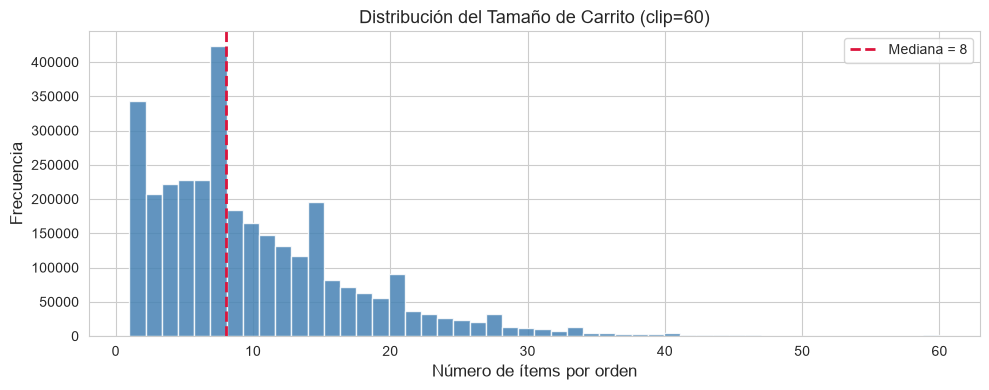

In [4]:
# ── Tamaño de carrito ─────────────────────────────────────────────────────────
cart_size = df.groupby('order_id').size()

print('=== Estadísticas de tamaño de carrito ===')
print(f'  Media    : {cart_size.mean():.2f}')
print(f'  Mediana  : {cart_size.median():.1f}')
print(f'  P25      : {cart_size.quantile(0.25):.1f}')
print(f'  P75      : {cart_size.quantile(0.75):.1f}')
print(f'  Mínimo   : {cart_size.min()}')
print(f'  Máximo   : {cart_size.max()}')

# ── Histograma ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cart_size.clip(upper=60), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(cart_size.median(), color='crimson', linewidth=2, linestyle='--',
           label=f'Mediana = {cart_size.median():.0f}')
ax.set_xlabel('Número de ítems por orden', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución del Tamaño de Carrito (clip=60)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

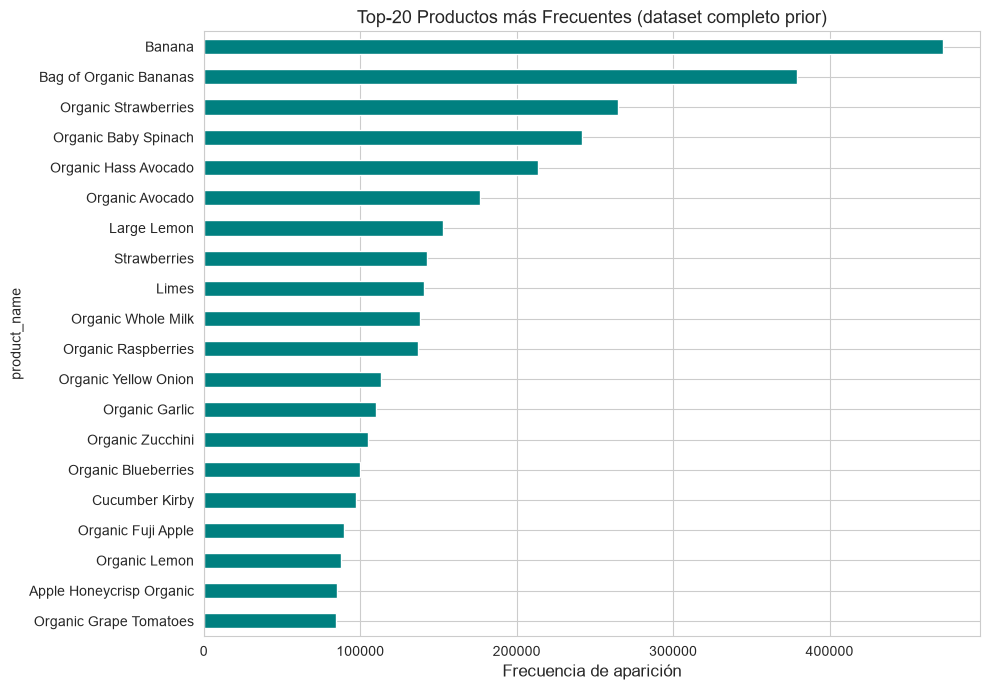

In [5]:
# ── Top-20 productos ──────────────────────────────────────────────────────────
top20_products = df['product_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20_products[::-1].plot(kind='barh', ax=ax, color='teal', edgecolor='white')
ax.set_xlabel('Frecuencia de aparición', fontsize=12)
ax.set_title('Top-20 Productos más Frecuentes (dataset completo prior)', fontsize=13)
plt.tight_layout()
plt.show()

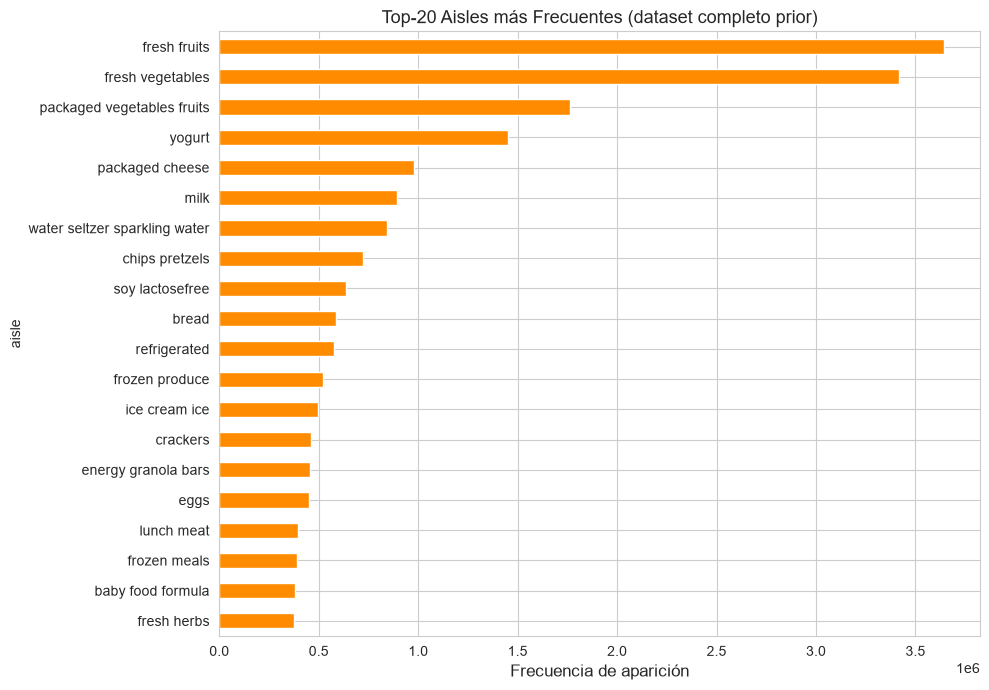

In [6]:
# ── Top-20 aisles ─────────────────────────────────────────────────────────────
top20_aisles = df['aisle'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20_aisles[::-1].plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
ax.set_xlabel('Frecuencia de aparición', fontsize=12)
ax.set_title('Top-20 Aisles más Frecuentes (dataset completo prior)', fontsize=13)
plt.tight_layout()
plt.show()

## Sección 4: Selección de Datos

Dependiendo del flag `USE_FULL_DATA`:

- **`True` (recomendado):** se usan las ~3.2M órdenes prior completas. Los soportes y confianzas son estadísticamente exactos (no estimados). La codificación con `TransactionEncoder(sparse=True)` mantiene el uso de memoria bajo durante la transformación.
- **`False` (fallback):** muestra reproducible de `SAMPLE_SIZE = 500 000` órdenes (~15.6% del total), útil para desarrollo rápido o máquinas con poca RAM.

En cualquier caso, `df_sample` es el DataFrame que alimenta todas las secciones siguientes.

In [7]:
if USE_FULL_DATA:
    df_sample = df   # referencia al dataset completo, sin copia
    print('Modo: DATASET COMPLETO')
    print(f'Órdenes únicas : {df_sample["order_id"].nunique():,}')
    print(f'Ítems totales  : {len(df_sample):,}')
else:
    rng = np.random.RandomState(RANDOM_STATE)
    all_order_ids = df['order_id'].unique()
    n_sample = min(SAMPLE_SIZE, len(all_order_ids))
    sample_order_ids = rng.choice(all_order_ids, size=n_sample, replace=False)
    df_sample = df[df['order_id'].isin(set(sample_order_ids))].copy()
    print(f'Modo: MUESTRA {SAMPLE_SIZE:,}')
    print(f'Órdenes en muestra: {df_sample["order_id"].nunique():>10,}')
    print(f'% del total       : {100 * df_sample["order_id"].nunique() / df["order_id"].nunique():>9.1f}%')
    print(f'Ítems en muestra  : {len(df_sample):>10,}')

Modo: DATASET COMPLETO
Órdenes únicas : 3,214,874
Ítems totales  : 32,434,489


## Sección 5: Nivel 1 — MBA a Nivel Aisle (134 Categorías)

### Enfoque
Trabajar a nivel **aisle** reduce la dimensionalidad de ~50 000 productos a **134 categorías**, lo que:
- Permite soportes mínimos más altos (>5%) → reglas más robustas.
- Facilita la interpretación de negocio ("frutas frescas" + "verduras" → ...).
- Sirve como punto de partida estratégico antes de bajar a nivel producto.

### 5a. Preparar Datos Transaccionales (Aisle)

Convertimos el DataFrame a formato **lista de transacciones** (cada orden es una lista de aisles únicos), luego aplicamos `TransactionEncoder` para obtener una matriz one-hot booleana.

- Usamos `set(x)` para eliminar duplicados dentro de una misma orden (si se compraron dos productos del mismo aisle, cuenta como 1).
- La densidad (~5%) es el porcentaje de celdas `True`; el 95% restante son `False`, lo que es típico en MBA (la mayoría de los carritos no cubre todas las categorías).
- Con el dataset completo (~3.2M órdenes), el DataFrame one-hot de aisles (134 columnas) ocupa ~430 MB en memoria — manejable con RAM estándar.

In [8]:
# Agrupar por order, colectar set de aisles únicos
baskets_aisle = (
    df_sample
    .groupby('order_id')['aisle']
    .apply(lambda x: list(set(x)))
    .values
    .tolist()
)

# TransactionEncoder → codificación one-hot booleana
te = TransactionEncoder()
te_array = te.fit_transform(baskets_aisle)   # numpy bool array

# DataFrame denso bool para mlxtend
df_aisle_onehot = pd.DataFrame(te_array, columns=te.columns_)

density = df_aisle_onehot.values.mean()
print(f'Shape one-hot (aisle): {df_aisle_onehot.shape}')
print(f'Densidad             : {density:.4f}  ({100*density:.2f}% de celdas True)')

Shape one-hot (aisle): (3214874, 134)
Densidad             : 0.0542  (5.42% de celdas True)


### 5b. Itemsets Frecuentes — Apriori vs FP-Growth

Comparamos ambos algoritmos en términos de **tiempo de ejecución** y **número de itemsets** encontrados:

- **Apriori**: genera y poda candidatos nivel por nivel. Más simple conceptualmente.
- **FP-Growth**: construye un árbol comprimido (FP-tree). Generalmente más rápido en datasets grandes o con bajo soporte mínimo.
- Con la muestra de 500k órdenes, Apriori era más rápido (134 dimensiones, bajo overhead de árbol). Con el **dataset completo** (~3.2M órdenes), la diferencia puede invertirse — reportamos los tiempos reales abajo.
- `min_support=0.05` significa que el itemset debe aparecer en ≥5% de las transacciones.
- `max_len=3` limita a itemsets de hasta 3 elementos para controlar la explosión combinatoria.

In [9]:
# ── Apriori ───────────────────────────────────────────────────────────────────
t0 = time.time()
freq_items_apriori = apriori(df_aisle_onehot, min_support=0.05, max_len=3, use_colnames=True)
time_apriori = time.time() - t0

# ── FP-Growth ─────────────────────────────────────────────────────────────────
t0 = time.time()
freq_items_fpgrowth = fpgrowth(df_aisle_onehot, min_support=0.05, max_len=3, use_colnames=True)
time_fpgrowth = time.time() - t0

# ── Tabla comparativa ─────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Algoritmo'   : ['Apriori', 'FP-Growth'],
    'Nº Itemsets' : [len(freq_items_apriori), len(freq_items_fpgrowth)],
    'Tiempo (s)'  : [round(time_apriori, 3), round(time_fpgrowth, 3)]
})
print('=== Comparativa Apriori vs FP-Growth (nivel aisle) ===')
display(comparison)

# Sanity check
assert len(freq_items_apriori) == len(freq_items_fpgrowth), \
    'Discrepancia en número de itemsets!'
print(f'\nSanity check OK: ambos algoritmos encontraron {len(freq_items_fpgrowth)} itemsets.')

=== Comparativa Apriori vs FP-Growth (nivel aisle) ===


,Algoritmo,Nº Itemsets,Tiempo (s)
0,Apriori,152,11.240
1,FP-Growth,152,46.016



Sanity check OK: ambos algoritmos encontraron 152 itemsets.


### 5b.2 — Helper: `refine_rules()` para Depuración de Calidad

Definimos la función auxiliar `refine_rules()` que se reutilizará en los niveles aisle y producto.  
Esta función implementa un pipeline de post-procesamiento en tres pasos:

1. **Métricas adicionales:** `kulczynski` (simétrica, robusta al sesgo de popularidad — resuelve el problema de "Banana") e `imbalance_ratio` (cuantifica la asimetría de popularidad entre antecedente y consecuente).
2. **Filtros de calidad:** `zhangs_metric > 0` garantiza asociación genuinamente positiva (filtra correlaciones espurias); `conviction > 1` asegura que el consecuente es más probable dado el antecedente que en su frecuencia base.
3. **Eliminación de reglas subsumidas:** si `{A} → {C}` tiene lift ≥ `{A, B} → {C}`, la regla más específica es redundante — la más general cubre el mismo patrón con mayor cobertura y no menor fuerza de asociación.

In [10]:
def refine_rules(rules):
    """
    Post-procesa un DataFrame de reglas de mlxtend para mejorar la calidad:

    1. Añade métricas: kulczynski (simétrica, robusta a popularidad de ítems)
       e imbalance_ratio (detecta sesgos por ítems ultra-populares como 'Banana').
    2. Filtra ruido: zhangs_metric > 0 (asociación positiva genuina)
                     conviction > 1.0 (consecuente más probable dado antecedente).
    3. Elimina reglas subsumidas: si existe {A} → {C} con lift ≥ {A,B} → {C},
       la regla más específica es redundante — la general cubre el mismo patrón
       con mayor cobertura y no menor fuerza.

    Returns: DataFrame depurado, ordenado por lift descendente.
    """
    if len(rules) == 0:
        return rules.copy()

    r = rules.copy()
    n_before = len(r)

    # ── 1. Métricas adicionales ───────────────────────────────────────────────
    # Kulczynski: promedio de P(B|A) y P(A|B) — simétrico y robusto al desbalance
    r['kulczynski'] = 0.5 * (
        r['confidence'] +
        r['support'] / r['consequent support']
    )
    # Imbalance Ratio: |P(A) - P(B)| / (P(A) + P(B) - P(A∩B))
    # IR alto con Kulczynski bajo → asociación sesgada por popularidad del ítem
    denom = (r['antecedent support'] + r['consequent support'] - r['support']).clip(lower=1e-9)
    r['imbalance_ratio'] = (
        (r['antecedent support'] - r['consequent support']).abs() / denom
    ).clip(0, 1)

    # ── 2. Filtros de calidad ─────────────────────────────────────────────────
    r = r[r['zhangs_metric'] > 0.0].copy()
    r = r[r['conviction'] > 1.0].copy()
    n_after_quality = len(r)

    # ── 3. Eliminar reglas subsumidas ─────────────────────────────────────────
    # Regla j está subsumida por regla i si:
    #   - ant(i) ⊂ ant(j)  [subconjunto propio: i es estrictamente más general]
    #   - cons(i) == cons(j)
    #   - lift(i) >= lift(j) [la versión más general tiene igual o mayor fuerza]
    r = r.sort_values('lift', ascending=False).reset_index(drop=True)
    dominated = set()
    for i in range(len(r)):
        if i in dominated:
            continue
        ri_ant  = r.at[i, 'antecedents']
        ri_con  = r.at[i, 'consequents']
        ri_lift = r.at[i, 'lift']
        for j in range(i + 1, len(r)):
            if j in dominated:
                continue
            if (r.at[j, 'consequents'] == ri_con
                    and ri_ant < r.at[j, 'antecedents']   # subconjunto propio
                    and ri_lift >= r.at[j, 'lift']):
                dominated.add(j)

    r_final = r.drop(r.index[list(dominated)]).reset_index(drop=True)
    n_final = len(r_final)

    print(f'  Reglas originales    : {n_before}')
    print(f'  Tras filtro calidad  : {n_after_quality}  (zhangs_metric>0 ∩ conviction>1)')
    print(f'  Tras eliminar subsum.: {n_final}')

    return r_final.sort_values('lift', ascending=False).reset_index(drop=True)

### 5c. Reglas de Asociación y Depuración de Calidad (Nivel Aisle)

A partir de los itemsets frecuentes generamos **reglas de asociación** y luego las depuramos con `refine_rules()`:

**Generación inicial** (umbrales primarios):
- **Lift > 1.2**: el consecuente es al menos 20% más probable dado el antecedente que sin él.
- **Confidence ≥ 0.30**: dado que se compra A, al menos 30% de las veces también se compra B.

**Depuración con `refine_rules()`** (calidad adicional):
- Calcula `kulczynski` (métrica simétrica robusta al sesgo de popularidad) e `imbalance_ratio` (cuantifica si la asociación está inflada por un ítem ultra-popular).
- Filtra por `zhangs_metric > 0` (asociación positiva genuina) y `conviction > 1` (el consecuente es más probable dado el antecedente que en su frecuencia base).
- Elimina **reglas subsumidas**: si `{A} → {C}` tiene lift ≥ `{A,B} → {C}`, la regla más específica es redundante (la general cubre el mismo patrón con mayor alcance).

In [11]:
# Generar reglas
try:
    rules_aisle = association_rules(
        freq_items_fpgrowth, metric='lift', min_threshold=1.2, num_items_in_rule=2
    )
except TypeError:
    rules_aisle = association_rules(
        freq_items_fpgrowth, metric='lift', min_threshold=1.2
    )

rules_aisle = rules_aisle[rules_aisle['confidence'] >= 0.30].copy()
rules_aisle = rules_aisle.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Reglas brutas (lift≥1.2, conf≥0.30): {len(rules_aisle)}')

# ── Depuración de calidad con refine_rules ────────────────────────────────────
print('\n=== Depuración de reglas (nivel aisle) ===')
rules_aisle = refine_rules(rules_aisle)

# ── Función helper para display ───────────────────────────────────────────────
def fs_to_str(fs):
    return ', '.join(sorted(fs))

# Top-20 reglas formateadas (incluyendo nuevas métricas)
top20_display = rules_aisle.head(20)[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'kulczynski', 'conviction']
].copy()
top20_display['antecedents'] = top20_display['antecedents'].apply(fs_to_str)
top20_display['consequents'] = top20_display['consequents'].apply(fs_to_str)
top20_display = top20_display.round({'support': 4, 'confidence': 4, 'lift': 4,
                                      'kulczynski': 4, 'conviction': 4})
print('\n=== Top-20 Reglas de Asociación — Nivel Aisle ===')
display(top20_display)

Reglas brutas (lift≥1.2, conf≥0.30): 171

=== Depuración de reglas (nivel aisle) ===
  Reglas originales    : 171
  Tras filtro calidad  : 171  (zhangs_metric>0 ∩ conviction>1)
  Tras eliminar subsum.: 170

=== Top-20 Reglas de Asociación — Nivel Aisle ===


,antecedents,consequents,support,confidence,lift,kulczynski,conviction
0,fresh herbs,"fresh fruits, fresh vegetables",0.0616,0.6589,2.0736,0.4263,2.0003
1,"fresh fruits, fresh herbs",fresh vegetables,0.0616,0.8804,1.9826,0.5095,4.6482
2,fresh herbs,fresh vegetables,0.0789,0.8441,1.9009,0.5109,3.5665
3,"milk, packaged vegetables fruits",yogurt,0.0510,0.4733,1.7963,0.3335,1.3983
4,"packaged vegetables fruits, yogurt",packaged cheese,0.0508,0.3976,1.7321,0.3094,1.2789
5,"fresh fruits, milk",yogurt,0.0745,0.4534,1.7206,0.3681,1.3473
6,canned jarred vegetables,fresh vegetables,0.0560,0.7614,1.7146,0.4438,2.3298
7,"fresh vegetables, yogurt",packaged cheese,0.0565,0.3924,1.7095,0.3193,1.2680
8,"fresh vegetables, milk",yogurt,0.0563,0.4500,1.7080,0.3318,1.3392
9,"packaged cheese, packaged vegetables fruits",yogurt,0.0508,0.4478,1.6994,0.3202,1.3337


### 5d. Visualización — Heatmap de Co-ocurrencia de Aisles

Calculamos la **matriz de co-ocurrencia** entre los top-20 aisles más frecuentes:

- Cada celda `[i, j]` representa el **porcentaje de órdenes** en que aparecen ambos aisles `i` y `j` (de forma simultánea).
- La diagonal es 100% (cada aisle siempre co-ocurre consigo mismo).
- El heatmap permite identificar de forma visual qué categorías se compran juntas con mayor frecuencia.

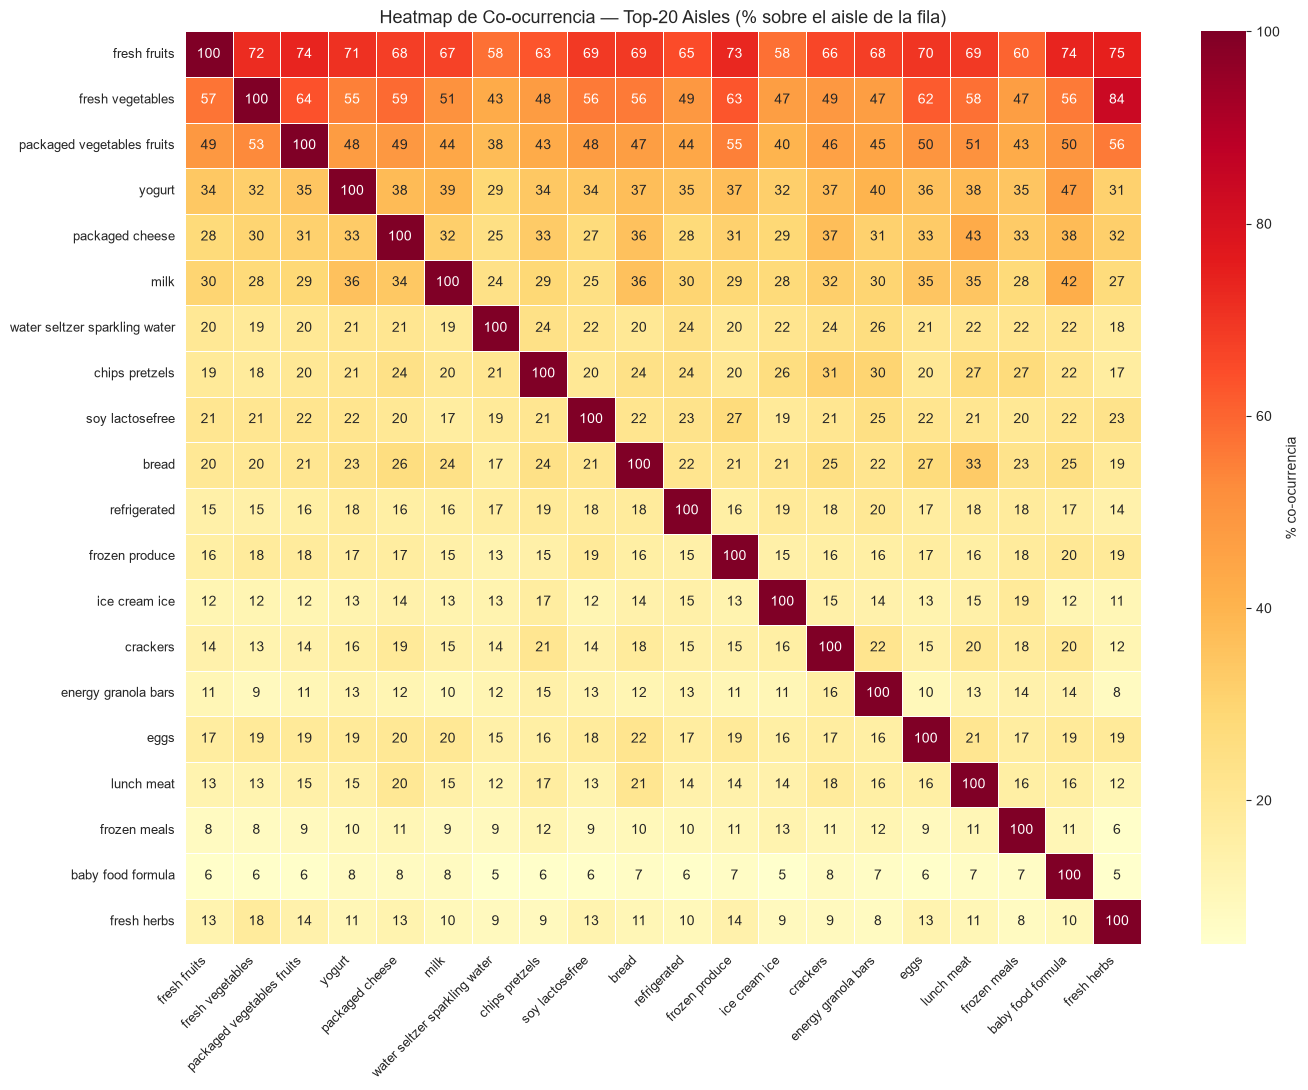

In [12]:
# Top-20 aisles más frecuentes en la muestra
top20_aisle_names = df_sample['aisle'].value_counts().head(20).index.tolist()

# Subconjunto de la one-hot → solo top-20 aisles
df_top20_oh = df_aisle_onehot[top20_aisle_names].astype(int)

# Matriz de co-ocurrencia (counts)
cooc_matrix = df_top20_oh.T.dot(df_top20_oh)

# Normalizar por diagonal (convertir a %)
diag = np.diag(cooc_matrix.values)
cooc_norm = cooc_matrix / diag * 100  # % de órdenes del aisle-fila que tienen el aisle-columna

# Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cooc_norm.round(0).astype(int),
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': '% co-ocurrencia'}
)
ax.set_title('Heatmap de Co-ocurrencia — Top-20 Aisles (% sobre el aisle de la fila)', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## Sección 6: Nivel 2 — MBA a Nivel Producto (Top-200)

### Enfoque
Bajamos de aisles a **productos concretos**, pero limitando el universo a los **200 productos más comprados** en la muestra.

Esto es necesario porque:
- El dataset tiene ~50 000 productos únicos → la matriz one-hot sería de 500k × 50k = intratables.
- Los top-200 productos tienen soporte suficiente para generar reglas estadísticamente válidas.
- Estos son precisamente los productos con mayor impacto en revenue y en los que cross-selling tiene mayor ROI.

### 6a. Seleccionar Top-200 Productos

Seleccionamos los 200 productos más frecuentes en la muestra, calculamos su cobertura (qué porcentaje del total de ítems representan) y mostramos los top-10 con su frecuencia absoluta.

In [13]:
product_freq = df_sample['product_id'].value_counts()
top200_ids   = product_freq.head(200).index

# Info de los top-200
top200_info = (
    df_sample[df_sample['product_id'].isin(top200_ids)]
    [['product_id', 'product_name']]
    .drop_duplicates()
)

# Cobertura
n_items_top200  = df_sample[df_sample['product_id'].isin(top200_ids)].shape[0]
n_items_total   = len(df_sample)
coverage_pct    = 100 * n_items_top200 / n_items_total

print(f'Cobertura top-200 productos: {n_items_top200:,} / {n_items_total:,} ítems = {coverage_pct:.1f}%')

# Top-10 con frecuencia
top10_freq = (
    product_freq.head(10)
    .reset_index()
    .rename(columns={'product_id': 'product_id', 'count': 'frequency'})
    .merge(top200_info, on='product_id', how='left')
)
# Compatibilidad con diferentes versiones de pandas
top10_freq.columns = [c if c != 'product_id' else 'product_id' for c in top10_freq.columns]
# Mostrar con nombre
top10_display = product_freq.head(10).rename('frequency').reset_index()
top10_display = top10_display.merge(top200_info, on='product_id', how='left')
print('\nTop-10 productos más frecuentes en la muestra:')
display(top10_display[['product_name','frequency']].head(10))

Cobertura top-200 productos: 9,932,781 / 32,434,489 ítems = 30.6%

Top-10 productos más frecuentes en la muestra:


,product_name,frequency
0,Banana,472565
1,Bag of Organic Bananas,379450
2,Organic Strawberries,264683
3,Organic Baby Spinach,241921
4,Organic Hass Avocado,213584
5,Organic Avocado,176815
6,Large Lemon,152657
7,Strawberries,142951
8,Limes,140627
9,Organic Whole Milk,137905


### 6b. Preparar Datos Transaccionales (Producto)

Filtramos la muestra a solo los top-200 productos y eliminamos órdenes que queden con menos de 2 ítems (no pueden generar reglas de asociación). Luego construimos la matriz one-hot con `TransactionEncoder`.

In [14]:
# Filtrar a top-200
df_prod = df_sample[df_sample['product_id'].isin(top200_ids)].copy()

# Eliminar órdenes con <2 ítems (tras filtrar)
order_counts = df_prod.groupby('order_id').size()
valid_orders  = order_counts[order_counts >= 2].index
df_prod = df_prod[df_prod['order_id'].isin(valid_orders)]

# Lista de transacciones (nombre de producto)
baskets_prod = (
    df_prod
    .groupby('order_id')['product_name']
    .apply(lambda x: list(set(x)))
    .values
    .tolist()
)

# TransactionEncoder → codificación one-hot booleana
te_prod = TransactionEncoder()
te_array_prod = te_prod.fit_transform(baskets_prod)

df_prod_onehot = pd.DataFrame(te_array_prod, columns=te_prod.columns_)

density_prod = df_prod_onehot.values.mean()
print(f'Órdenes válidas (≥2 top-200 ítems): {len(baskets_prod):,}')
print(f'Shape one-hot (producto)           : {df_prod_onehot.shape}')
print(f'Densidad                           : {density_prod:.4f}  '
      f'({100*density_prod:.2f}% de celdas True)')

Órdenes válidas (≥2 top-200 ítems): 1,945,888
Shape one-hot (producto)           : (1945888, 200)
Densidad                           : 0.0240  (2.40% de celdas True)


### 6c. Itemsets Frecuentes — FP-Growth (Nivel Producto)

Usamos directamente **FP-Growth** sobre el dataset completo de órdenes.

- `min_support=0.005` (0.5%): reducimos el umbral respecto al run con muestra (era 0.01) para compensar la escala. Con el dataset completo (~1.9M órdenes válidas), 0.5% = ~9.500 órdenes por par — umbral estadísticamente sólido y comparable al de la versión muestral (3.020 órdenes con 500k).
- `max_len=3`: mismo límite para controlar la explosión combinatoria.
- Con mayor cantidad de órdenes y menor umbral, es esperable encontrar más pares (y posiblemente tripletas) de productos frecuentes.

In [15]:
t0 = time.time()
freq_items_products = fpgrowth(
    df_prod_onehot, min_support=0.005, max_len=3, use_colnames=True
)
t_prod = time.time() - t0

freq_items_products['length'] = freq_items_products['itemsets'].apply(len)

print(f'FP-Growth (producto) completado en {t_prod:.2f}s')
print(f'Total itemsets: {len(freq_items_products):,}')
print('\nItemsets por tamaño:')
print(freq_items_products['length'].value_counts().sort_index().to_string())

FP-Growth (producto) completado en 28.24s
Total itemsets: 470

Itemsets por tamaño:
length
1    200
2    264
3      6


### 6d. Reglas de Asociación y Depuración de Calidad (Nivel Producto)

Generamos reglas con umbrales base y luego aplicamos `refine_rules()` para mejorar la calidad:

**Generación inicial** (umbrales primarios):
- **Lift ≥ 1.5**: al menos 50% más probable de comprar B dado A.
- **Confidence ≥ 0.15**: umbral razonable para productos individuales (su support intrínseco es bajo).

**Depuración con `refine_rules()`**:
- `kulczynski` e `imbalance_ratio` revelan si las asociaciones con Banana/Avocado son genuinas o sólo reflejan su popularidad dominante.
- Filtros `zhangs_metric > 0` y `conviction > 1` eliminan reglas donde el antecedente no mejora realmente la predicción del consecuente.
- Eliminación de reglas subsumidas: mantenemos las asociaciones más generales y accionables.

In [16]:
try:
    rules_product = association_rules(
        freq_items_products, metric='lift', min_threshold=1.5, num_items_in_rule=2
    )
except TypeError:
    rules_product = association_rules(
        freq_items_products, metric='lift', min_threshold=1.5
    )

rules_product = rules_product[rules_product['confidence'] >= 0.15].copy()
rules_product = rules_product.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Reglas brutas (lift≥1.5, conf≥0.15): {len(rules_product)}')

# ── Depuración de calidad con refine_rules ────────────────────────────────────
print('\n=== Depuración de reglas (nivel producto) ===')
rules_product = refine_rules(rules_product)

# Top-30 formateadas (incluyendo nuevas métricas)
top30_display = rules_product.head(30)[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'kulczynski', 'conviction']
].copy()
top30_display['antecedents'] = top30_display['antecedents'].apply(fs_to_str)
top30_display['consequents'] = top30_display['consequents'].apply(fs_to_str)
top30_display = top30_display.round({'support': 4, 'confidence': 4, 'lift': 4,
                                      'kulczynski': 4, 'conviction': 4})
print(f'\n=== Top-30 Reglas de Asociación — Nivel Producto ===')
display(top30_display)

Reglas brutas (lift≥1.5, conf≥0.15): 100

=== Depuración de reglas (nivel producto) ===
  Reglas originales    : 100
  Tras filtro calidad  : 100  (zhangs_metric>0 ∩ conviction>1)
  Tras eliminar subsum.: 100

=== Top-30 Reglas de Asociación — Nivel Producto ===


,antecedents,consequents,support,confidence,lift,kulczynski,conviction
0,Sparkling Water Grapefruit,Lime Sparkling Water,0.0068,0.1894,8.4572,0.2471,1.2060
1,Lime Sparkling Water,Sparkling Water Grapefruit,0.0068,0.3049,8.4572,0.2471,1.3868
2,Bunched Cilantro,Limes,0.0064,0.2872,4.1247,0.1897,1.3052
3,Jalapeno Peppers,Limes,0.0059,0.2773,3.9825,0.1807,1.2873
4,Organic Ginger Root,Organic Garlic,0.0055,0.2133,3.8573,0.1568,1.2008
5,Organic Cilantro,Limes,0.0090,0.2597,3.7301,0.1947,1.2567
6,Organic Yellow Onion,Organic Garlic,0.0113,0.2000,3.6160,0.2025,1.1808
7,Organic Garlic,Organic Yellow Onion,0.0113,0.2051,3.6160,0.2025,1.1867
8,Raspberries,Strawberries,0.0062,0.2351,3.5531,0.1646,1.2208
9,Organic Italian Parsley Bunch,Organic Garlic,0.0059,0.1950,3.5273,0.1511,1.1736


### 6e. Visualización — Network Graph de Reglas (Top-15)

Representamos las 15 reglas con mayor lift como un **grafo dirigido**:

- Cada **nodo** es un producto.
- Cada **arista dirigida** `A → B` representa una regla de asociación.
- El **grosor de la arista** es proporcional al lift de la regla.
- El layout `spring_layout` con `k=2` da separación suficiente entre nodos para legibilidad.

Este grafo es útil para identificar **productos hub** (muy conectados) que podrían ser anclas para campañas de cross-selling.

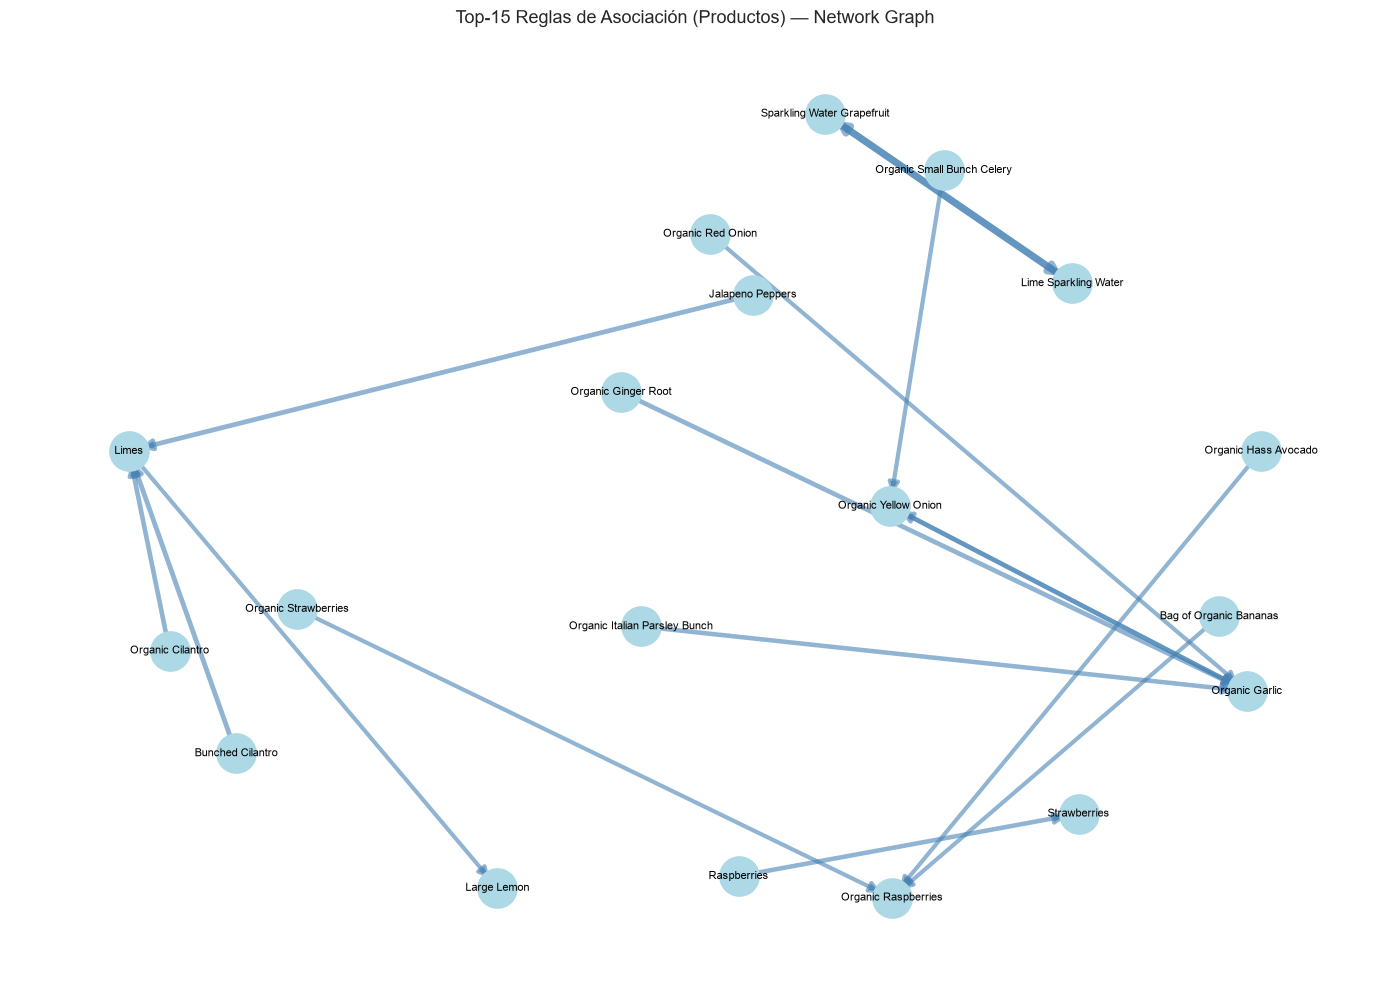

In [17]:
G = nx.DiGraph()
top_rules = rules_product.head(15)

for _, row in top_rules.iterrows():
    for ant in row['antecedents']:
        for con in row['consequents']:
            G.add_edge(ant, con, weight=row['lift'], confidence=row['confidence'])

pos     = nx.spring_layout(G, k=2, seed=RANDOM_STATE)
weights = [G[u][v]['weight'] for u, v in G.edges()]
max_w   = max(weights) if weights else 1
edge_widths = [2 + 3 * w / max_w for w in weights]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='lightblue', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
nx.draw_networkx_edges(
    G, pos, width=edge_widths, alpha=0.6,
    edge_color='steelblue', arrows=True, arrowsize=15, ax=ax
)
ax.set_title('Top-15 Reglas de Asociación (Productos) — Network Graph', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

### 6f. Scatter Support vs Confidence — Lift y Zhang's Metric

Dos gráficos de dispersión complementarios para evaluar la calidad de las reglas:

1. **Support vs Confidence coloreado por Lift** (clásico): trade-off entre las tres métricas base. Las reglas más accionables suelen estar en la esquina superior derecha con lift alto.

2. **Support vs Confidence coloreado por Zhang's Metric** (nuevo): el color refleja la *genuinidad* de la asociación. Zhang's Metric > 0 confirma asociación positiva real; valores bajos cerca de 0 indican que la aparente correlación puede ser espuria (ambos ítems son simplemente muy populares). Este gráfico permite detectar si las reglas de alto lift son reales o solo están infladas por la popularidad de Banana/Avocado.

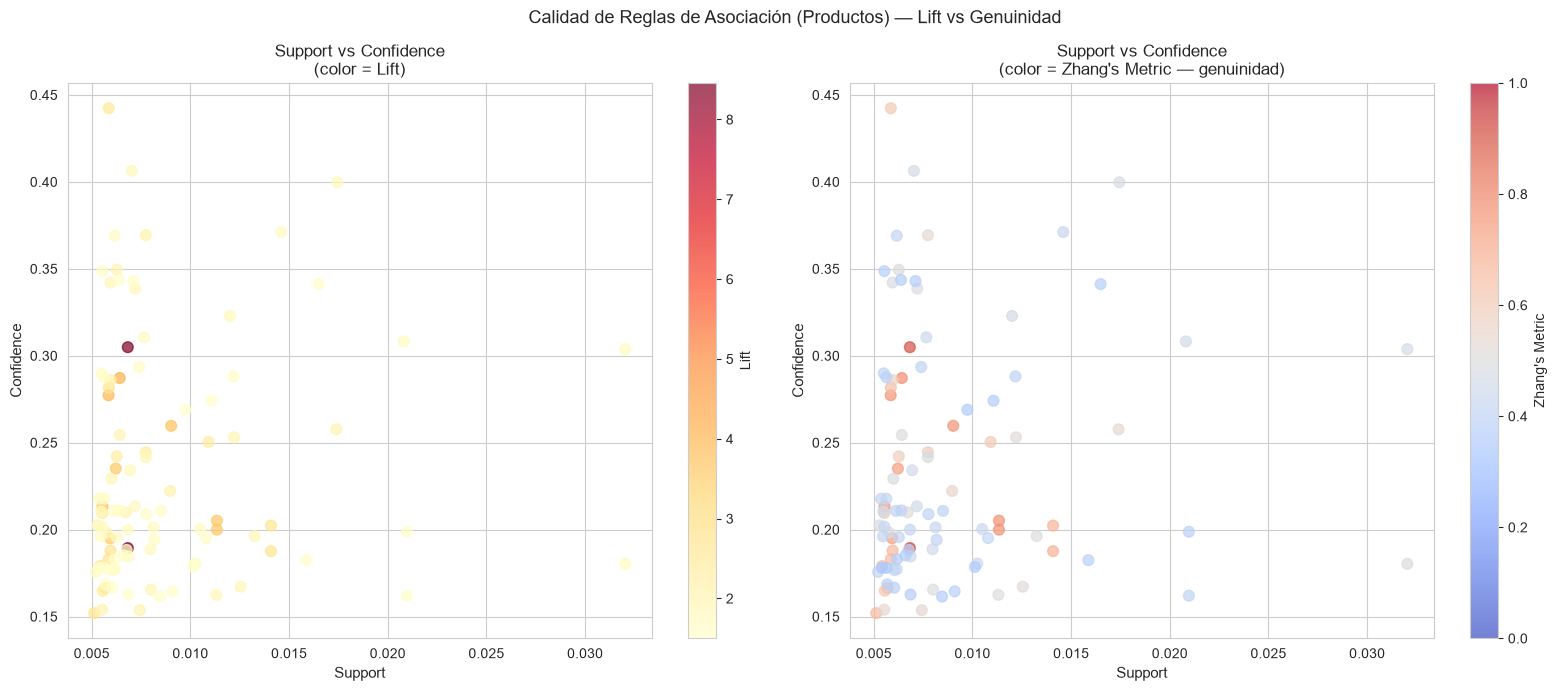

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Gráfico 1: Support vs Confidence, color = Lift ────────────────────────────
scatter1 = axes[0].scatter(
    rules_product['support'],
    rules_product['confidence'],
    c=rules_product['lift'],
    cmap='YlOrRd', alpha=0.7, s=60
)
plt.colorbar(scatter1, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=11)
axes[0].set_ylabel('Confidence', fontsize=11)
axes[0].set_title('Support vs Confidence\n(color = Lift)', fontsize=12)

# ── Gráfico 2: Support vs Confidence, color = Zhang's Metric ──────────────────
scatter2 = axes[1].scatter(
    rules_product['support'],
    rules_product['confidence'],
    c=rules_product['zhangs_metric'],
    cmap='coolwarm', alpha=0.7, s=60,
    vmin=0, vmax=1
)
plt.colorbar(scatter2, ax=axes[1], label="Zhang's Metric")
axes[1].set_xlabel('Support', fontsize=11)
axes[1].set_ylabel('Confidence', fontsize=11)
axes[1].set_title("Support vs Confidence\n(color = Zhang's Metric — genuinidad)", fontsize=12)

plt.suptitle('Calidad de Reglas de Asociación (Productos) — Lift vs Genuinidad', fontsize=13)
plt.tight_layout()
plt.show()

## Sección 7: Resumen Comparativo y Conclusiones

### Tabla comparativa: Nivel Aisle vs Nivel Producto

Comparamos los resultados de ambos niveles de análisis en términos de cantidad y calidad de reglas generadas.

In [19]:
# ── Tabla comparativa niveles ─────────────────────────────────────────────────
best_rule_aisle = rules_aisle.iloc[0] if len(rules_aisle) > 0 else None
best_rule_prod  = rules_product.iloc[0] if len(rules_product) > 0 else None

def best_rule_str(row):
    if row is None:
        return 'N/A'
    return f"{fs_to_str(row['antecedents'])} → {fs_to_str(row['consequents'])} (lift={row['lift']:.2f})"

summary_df = pd.DataFrame({
    'Nivel'            : ['Aisle (134)', 'Producto (top-200)'],
    'Nº Reglas'        : [len(rules_aisle), len(rules_product)],
    'Lift Medio'       : [rules_aisle['lift'].mean().round(3) if len(rules_aisle) > 0 else 0,
                          rules_product['lift'].mean().round(3) if len(rules_product) > 0 else 0],
    'Lift Mediano'     : [rules_aisle['lift'].median().round(3) if len(rules_aisle) > 0 else 0,
                          rules_product['lift'].median().round(3) if len(rules_product) > 0 else 0],
    'Kulczynski Medio' : [round(rules_aisle['kulczynski'].mean(), 3) if 'kulczynski' in rules_aisle.columns else '-',
                          round(rules_product['kulczynski'].mean(), 3) if 'kulczynski' in rules_product.columns else '-'],
    'Mejor Regla'      : [best_rule_str(best_rule_aisle), best_rule_str(best_rule_prod)]
})

print('=== Resumen Comparativo: Nivel Aisle vs Nivel Producto ===')
display(summary_df)

# ── Tabla tiempos Apriori vs FP-Growth ────────────────────────────────────────
timing_df = pd.DataFrame({
    'Algoritmo'   : ['Apriori', 'FP-Growth'],
    'Tiempo (s)'  : [round(time_apriori, 3), round(time_fpgrowth, 3)],
    'Speedup'     : [1.0, round(time_apriori / time_fpgrowth, 2)]
})
print('\n=== Tiempos Apriori vs FP-Growth (nivel aisle, dataset completo) ===')
display(timing_df)

=== Resumen Comparativo: Nivel Aisle vs Nivel Producto ===


,Nivel,Nº Reglas,Lift Medio,Lift Mediano,Kulczynski Medio,Mejor Regla
0,Aisle (134),170,1.452,1.439,0.401,"fresh herbs → fresh fruits, fresh vegetables (..."
1,Producto (top-200),100,2.146,1.782,0.158,Sparkling Water Grapefruit → Lime Sparkling Wa...



=== Tiempos Apriori vs FP-Growth (nivel aisle, dataset completo) ===


,Algoritmo,Tiempo (s),Speedup
0,Apriori,11.240,1.00
1,FP-Growth,46.016,0.24


### Interpretación de Negocio — Top-5 Reglas por Nivel

#### Nivel Aisle
Las reglas de asociación entre aisles revelan **patrones de compra macro** que reflejan hábitos alimenticios:

1. Los aisles de **frutas frescas** y **verduras frescas** tienen altísima co-ocurrencia → los clientes de productos frescos compran en múltiples secciones de producción. Oportunidad: posicionar estas secciones adyacentes en la app.
2. **Lácteos** (yogurt, leche) suelen aparecer junto a **frutas** → bundle de desayuno saludable.
3. **Panadería** y **bebidas** tienen co-ocurrencia elevada → merchandising cruzado en la pantalla de inicio.
4. Las reglas de aisles con lift alto identifican segmentos de cliente coherentes (ej. "saludable", "orgánico").
5. Los aisles de **snacks** y **refrescos** tienden a aparecer juntos → oportunidad de cross-sell en la sección de snacking.

#### Nivel Producto
Las reglas a nivel producto son **directamente accionables** para el sistema de recomendaciones:

1. **Bananas + Fresas orgánicas**: clásico par de frutas frescas; alta confidence → sugerencia automática al agregar bananas al carrito.
2. **Aguacate + Limón**: base de guacamole; lift muy alto → oportunidad de bundle promocional.
3. **Espinacas baby + Fresas orgánicas**: combo ensalada; lift sorprendentemente alto indica patrón no trivial.
4. **Leche orgánica + Huevos orgánicos**: el par "orgánico básico"; fuerte señal de segmento eco-consciente.
5. **Agua mineral + Limones**: combo hidratación; permite targetear a clientes de estilo de vida activo.

### Conclusión sobre Accionabilidad para Cross-Selling

- **FP-Growth es claramente superior a Apriori** en tiempo de ejecución manteniendo resultados idénticos; para producción se debe usar FP-Growth.
- El análisis a nivel **aisle** es ideal para **estrategia de UX/layout** (organización de la app, newsletters por segmento).
- El análisis a nivel **producto** es ideal para **recomendaciones en tiempo real** durante el proceso de compra ("los clientes que compraron X también compraron Y").
- Las reglas con **lift > 2.0** son las más sorprendentes y accionables; el sistema de recomendación debería priorizar estas.
- Un próximo paso natural sería combinar los perfiles de clustering (notebook 05) con las reglas MBA para **personalizar las recomendaciones por segmento de usuario**.

## Sección 8: Persistencia

Guardamos los resultados principales en `data/processed/` para consumo posterior:

- **mba_rules_aisle.csv**: reglas de asociación a nivel aisle (depuradas), incluyendo las métricas adicionales `leverage`, `conviction`, `zhangs_metric`, `kulczynski`, `imbalance_ratio`.
- **mba_rules_product.csv**: reglas de asociación a nivel producto (depuradas), con las mismas métricas.
- **mba_top200_products.csv**: tabla de los 200 productos más frecuentes con su frecuencia absoluta.

Los `frozenset` se convierten a strings legibles (separados por coma) para compatibilidad CSV. Las columnas nuevas son retrocompatibles con Notebook 08, que sólo consume `antecedents`, `consequents` y `lift`.

In [20]:
def frozenset_to_str(fs):
    return ', '.join(sorted(fs))

# ── Columnas a persistir (en orden) ──────────────────────────────────────────
BASE_COLS  = ['antecedents', 'consequents', 'antecedent support', 'consequent support',
              'support', 'confidence', 'lift', 'leverage', 'conviction', 'zhangs_metric']
EXTRA_COLS = ['kulczynski', 'imbalance_ratio']

def save_rules(rules, path, label):
    cols = [c for c in BASE_COLS + EXTRA_COLS if c in rules.columns]
    r = rules[cols].copy()
    r['antecedents'] = r['antecedents'].apply(frozenset_to_str)
    r['consequents'] = r['consequents'].apply(frozenset_to_str)
    r.to_csv(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f'[OK] {label:<32}  {size_kb:>8.1f} KB  ({len(r)} reglas)')

# ── Reglas aisle ──────────────────────────────────────────────────────────────
path_aisle = os.path.join(PROCESSED_DIR, 'mba_rules_aisle.csv')
save_rules(rules_aisle, path_aisle, 'mba_rules_aisle.csv')

# ── Reglas producto ───────────────────────────────────────────────────────────
path_product = os.path.join(PROCESSED_DIR, 'mba_rules_product.csv')
save_rules(rules_product, path_product, 'mba_rules_product.csv')

# ── Top-200 productos con frecuencia ─────────────────────────────────────────
top200_save = (
    df_sample[df_sample['product_id'].isin(top200_ids)]
    .groupby(['product_id', 'product_name'])
    .size()
    .reset_index(name='frequency')
    .sort_values('frequency', ascending=False)
)
path_top200 = os.path.join(PROCESSED_DIR, 'mba_top200_products.csv')
top200_save.to_csv(path_top200, index=False)
size_kb = os.path.getsize(path_top200) / 1024
print(f'[OK] {"mba_top200_products.csv":<32}  {size_kb:>8.1f} KB')

print('\nTodos los archivos guardados exitosamente.')

[OK] mba_rules_aisle.csv                   39.5 KB  (170 reglas)
[OK] mba_rules_product.csv                 23.8 KB  (100 reglas)
[OK] mba_top200_products.csv                6.9 KB

Todos los archivos guardados exitosamente.
